In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader
from src.data.synthetic_sofr_builder import build_term_sofr_curve

from src.term_structure.curve_merger import merge_curves
from src.term_structure.bootstrapping import (
    build_coupon_structure,
    bootstrap_dfs_from_sofr,
    bootstrap_dfs_from_treasury
)
from src.term_structure.curve_interpolator import log_linear_curve_interpolator
from src.term_structure.curve_builder import (
    build_zero_curve,
    build_forward_curve
)

from src.pricing.swap_pricing_engine import par_swap_curve

from src.hedging.hedge_instruments import (
    HedgeInstrument,
    HedgeUniverse
)
from src.hedging.hedge_ratio import HedgeRatio

from src.factors.yield_curve_pca import YieldCurvePCA
from src.factors.factor_risk import FactorRiskModel

from src.portfolio.swap_object import IRSwap
from src.portfolio.swap_portfolio import SwapPortfolio

from src.scenario.scenario_engine import ScenarioEngine

from src.rebalancing.hedge_optimizer import HedgeOptimizer
from src.rebalancing.transaction_cost import TransactionCostModel
from src.rebalancing.rolling_hedge_engine import RollingHedgeEngine

In [2]:
### Curve Builder
# downloading market curves
loader = MarketLoader()
curves = loader.loader_pipeline()

# building synthetic sofr curve from ON rates and futures
sofr_curve = build_term_sofr_curve(curves = curves)

# bootstrapping discount factors from sofr curve
df_sofr = bootstrap_dfs_from_sofr(
    sofr_curve = sofr_curve
)

# extracting treasury curve 
treasury_curve = curves['treasury']

# bootstrapping discount factors from treasury curve
df_treasury = bootstrap_dfs_from_treasury(
    treasury_curve = treasury_curve,
    short_dfs = df_sofr
)

# concatenating short-end and long-end into a single curve -> full curve
df_full_curve = merge_curves(
    short_curve = df_sofr,
    long_curve = df_treasury
)

# constructing semi-annual coupon structure
coupon_structure = build_coupon_structure(
    max_year = 30,
    freq = 2
)

# log-linear discount curve interpolation
df_loglinear_interp = log_linear_curve_interpolator(
    df_curve = df_full_curve,
    _target_times = coupon_structure
)

# building zero curve from log-linear discount curve
zero_curve_full = build_zero_curve(
    df_curve = df_loglinear_interp
)

# building forward curve from log-linear discount curve
forward_curve_full = build_forward_curve(
    df_curve = df_loglinear_interp
)

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..


In [3]:
### PCA Model
# defining key-rate tenors
keyrate_tenors = [2.0, 5.0, 10.0, 30.0]

# building PCA model for yield curve risk factors
pca_model = YieldCurvePCA(n_factors = 3)

# fitting PCA model
pca_model.fit(zero_curve = zero_curve_full, key_rate_tenors = keyrate_tenors)     # type: ignore

# explained variance
display(pca_model.explained_variance())

,EigenValue,Explained_Variance,Cumulative_Explained
Factor_0,1.038373e-06,0.847016,0.847016
Factor_1,1.654544e-07,0.134964,0.981980
Factor_2,2.209103e-08,0.018020,1.000000


In [4]:
### Swap Portfolio
# building swap portfolio
swap_list = [
    IRSwap(maturity = 4.0, fixed_rate = 0.0388, notional = 16_500_000, pay_receive = 'payer', freq = 2),
    IRSwap(maturity = 12.0, fixed_rate = 0.0442, notional = 22_750_000, pay_receive = 'receiver', freq = 2)
]

# creating swap portfolio instance
swap_portfolio = SwapPortfolio(swaps = swap_list)
swap_portfolio.summary()

,TradeID,Type,Maturity,FixedRate,Notional,CouponFrequency
0,0,payer,4.0,0.0388,16500000,2
1,1,receiver,12.0,0.0442,22750000,2


In [5]:
### Portfolio DV01 timeseries
# portfolio dv01 - key_rate
portfolio_keyrate_dv01_ts = swap_portfolio.portfolio_dv01(
    df_curve = df_loglinear_interp,
    shock_type = 'key_rate',
    key_rate_tenors = keyrate_tenors
)

print('--- Portfolio DV01 (Key-Rate) --')
portfolio_keyrate_dv01_ts

--- Portfolio DV01 (Key-Rate) --


,Portfolio_DV01_2Y,Portfolio_DV01_5Y,Portfolio_DV01_10Y,Portfolio_DV01_30Y
2018-04-03,157.3,220.8,380.2,0.0
2018-04-04,157.3,220.7,380.2,0.0
2018-04-05,157.1,220.3,378.7,0.0
2018-04-06,157.3,221.0,380.9,0.0
2018-04-09,157.3,220.8,380.6,0.0
...,...,...,...,...
2026-04-15,152.7,207.1,327.1,0.0
2026-04-16,152.7,207.0,326.1,0.0
2026-04-17,152.9,207.7,328.0,0.0
2026-04-20,152.9,207.5,328.0,0.0


In [6]:
### Hedge Universe
# extracting latest par swap curve
latest_par_swap_curve = par_swap_curve(
    df_curve = df_loglinear_interp,
    maturities= [2.0, 5.0, 10.0, 30.0],
    freq = 2
).iloc[-1]

# creating hedge instruments
hedges = [
    HedgeInstrument('HedgeSwap_2Y', 2.0, fixed_rate = float(latest_par_swap_curve.loc[2])),
    HedgeInstrument('HedgeSwap_5Y', 5.0, fixed_rate = float(latest_par_swap_curve.loc[5])),
    HedgeInstrument('HedgeSwap_10Y', 10.0, fixed_rate = float(latest_par_swap_curve.loc[10])),
    HedgeInstrument('HedgeSwap_30Y', 30.0, fixed_rate = float(latest_par_swap_curve.loc[30]))
]

# hedge universe
hedge_universe = HedgeUniverse(
    instruments = hedges
)

# building hedge swaps
hedge_swaps = hedge_universe.build_IRswaps()

display(hedge_universe.summary())

# creating hedge swap portfolio instance
hedgeSwaps_portfolio = SwapPortfolio(swaps = hedges)

,Instrument,Type,Maturity,Par Rate,Notional,CouponFreq
0,HedgeSwap_2Y,receiver,2.0,0.0378,1000000,2
1,HedgeSwap_5Y,receiver,5.0,0.0391,1000000,2
2,HedgeSwap_10Y,receiver,10.0,0.0430,1000000,2
3,HedgeSwap_30Y,receiver,30.0,0.0489,1000000,2


In [7]:
### Hedge Portfolio DV01 timeseries
# hedge portfolio dv01 - key_rate
hedge_portfolio_keyrate_dv01_ts = hedgeSwaps_portfolio.portfolio_dv01(
    df_curve = df_loglinear_interp,
    shock_type = 'key_rate',
    key_rate_tenors = keyrate_tenors
)

print('--- Hedge Portfolio DV01 (Key-Rate) --')
hedge_portfolio_keyrate_dv01_ts

--- Hedge Portfolio DV01 (Key-Rate) --


,Portfolio_DV01_2Y,Portfolio_DV01_5Y,Portfolio_DV01_10Y,Portfolio_DV01_30Y
2018-04-03,207.2,467.8,790.9,1230.2
2018-04-04,207.2,467.5,791.0,1225.9
2018-04-05,207.1,466.9,787.7,1211.1
2018-04-06,207.3,468.2,792.5,1233.3
2018-04-09,207.2,467.8,791.8,1229.7
...,...,...,...,...
2026-04-15,201.2,439.0,680.5,673.1
2026-04-16,201.1,438.8,678.4,663.8
2026-04-17,201.4,440.3,682.2,673.4
2026-04-20,201.4,439.8,682.5,673.6


In [8]:
### Factor Risk Model
# creating factor risk model instance
factor_risk_model = FactorRiskModel(pca_model = pca_model)

In [9]:
### Hedge Optimizer
# creating hedge optimizer instance
optimizer = HedgeOptimizer(
    factor_risk_model = factor_risk_model,
    key_rate_tenors = keyrate_tenors
)

In [10]:
### Transaction Cost Model
# defining spread dictionary
spread_dict = {
    '2Y': 0.5,
    '5Y': 0.7,
    '10Y': 1.0,
    '30Y': 1.2
}

# creating transaction cost model instance
tc_model = TransactionCostModel(
    hedge_universe = hedge_universe,
    custom_spread_bps = spread_dict,
    impact_coeff = 0.10,
    daily_vol_bps = 7.0,
    fixed_cost = 20
)

In [ ]:
### Rolling Hedge Backtest
# creating rolling hedge engine instance
rh_engine = RollingHedgeEngine(
    hedge_engine = optimizer,
    transaction_cost_model = tc_model,
    rebalance_frequency = 'ME'  
)

# dynamic rolling hedge simulator
rh_engine.rolling_hedge_simulator(
    portfolio = swap_portfolio,
    hedge_universe = hedge_universe,
    df_curve = df_loglinear_interp,
    key_rate_tenors = keyrate_tenors
)

# compute hedged PnL timeseries
pnl = rh_engine.compute_pnl(
    portfolio = swap_portfolio,
    hedge_universe = hedge_universe,
    df_curve = df_loglinear_interp,
    key_rate_tenors = keyrate_tenors
)

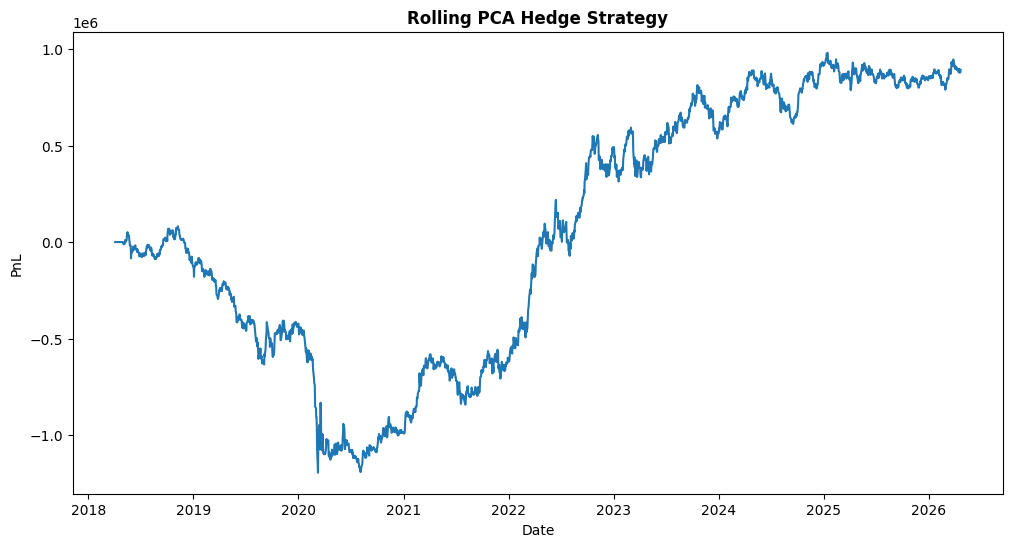

In [16]:
# plotting PCA Hedge Strategy
plt.figure(figsize=(12, 6))

plt.plot(pnl.index, pnl.values)
plt.title('Rolling PCA Hedge Strategy', fontweight = 'bold')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.show()